<a href="https://colab.research.google.com/github/praksb2428-maker/Deep.practice/blob/main/02_logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 6장. 로지스틱 회귀 모델: 참 거짓 판단하기

## 5. 텐서플로에서 실행하는 로지스틱 회귀 모델

### 1.환경 준비

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

### 2. 데이터 준비

In [ ]:
x = np.array([2, 4, 6, 8, 10, 12, 14])
y = np.array([0, 0, 0, 1, 1, 1, 1])

### 3. 모델 실행

In [21]:
model = Sequential()
model.add(Dense(1, input_dim=1, activation='sigmoid'))

# 교차 엔트로피 오차 함수를 이용하기 위하여 'binary_crossentropy'로 설정합니다.
model.compile(optimizer='sgd' ,loss='binary_crossentropy')
model.fit(x, y, epochs=100, verbose=1) #verbose=1 진행 화면 출력, verbose=0 진행 화면 출력 안함.

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - loss: 1.4286
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 1.4003
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 1.3720
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 1.3439
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 1.3160
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 1.2883
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 1.2607
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 1.2333
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 1.2061
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 1.1792
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 1.1524
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 1.1259
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 1.0997
Epoch 14/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 1.0737
Epoch 15/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 1.0481
Epoch 16/100
1/1 ━

### 4. 모델 테스트

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


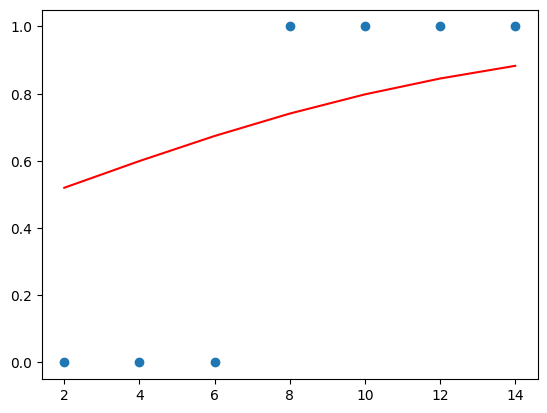

In [22]:
# 그래프로 확인해 봅니다.

plt.scatter(x, y)
plt.plot(x, model.predict(x),'r')
plt.show()

In [ ]:
import tensorflow as tf

# 임의의 학습 시간을 집어넣어 합격 예상 확률을 예측해 보겠습니다.

hour = 7
#prediction = model.predict([hour]) #텐서플로 2.9.0 까지만 가능

input_data = tf.constant([[hour]])
prediction = model.predict(input_data)[0][0]


print("%.f시간을 공부할 경우, 합격 예상 확률은 %.01f%%입니다" % (hour, prediction * 100))

7시간을 공부할 경우, 합격 예상 확률은 59.7%입니다


# 실습 문제

epoch, loss type 등을 바꿔서 실행해보고 결과를 비교 후 이유를 적어보세요

- 파라미터 변경사항 작성
- 결과 비교 작성
- 이유 작성

epoch의 기존 횟수가 2000번 에서 20으로 줄였을 때 loss 오차값이 높아진 것 을 확인 할 수 있었다. epoch의 숫자가 컸던 이유는 오차값을 줄이기 위해 반복횟수를 높게 잡았고 20회로 했을 때 오차값이 높은 것을 확인 할 수 있었음. 때문에 오차값을 줄이기 위해 반복횟수를 가능한 높게 잡게하여 loss가 0또는 1이 될때까지 돌리면 오차값이 적어지는 것을 알 수 있다.

오차값이 적을 때 그래프와 오차값이 클 때 그래프와는 차이가 있었고 그 차이는 epoch를 돌리는 횟수에 따라서 결과값이 달라지는 것을 확인 할 수 있었다. 많은 실행을 통하여 보다 정확한 결과값을 얻기 위해 epoch의 횟수를 높게 잡아야 한다는 것을 알 수 있다.